# 📊 Matrices de Confusion Finales
Ce notebook génère explicitement les matrices de confusion pour notre architecture Zoidberg.
1. Matrice Globale à 3 classes (Sain, Bactérie, Virus) via le pipeline complet.
2. Matrice Spécialisée à 2 classes (Bactérie vs Virus) via le modèle expert.

⏳ Chargement des données de test globales...
Found 3469 images belonging to 3 classes.
Found 867 images belonging to 3 classes.
Found 1402 images belonging to 3 classes.
🔍 Évaluation des images (Pipeline à 2 étages)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

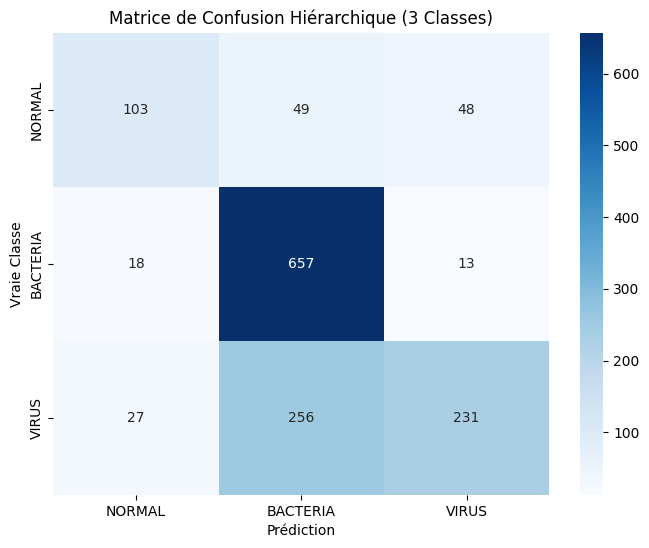

In [1]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import sys
sys.path.append('..')

from src.data.data_loader_v3 import create_multiclass_generators
from src.models.hierarchical_pipeline import HierarchicalClassifier

print("⏳ Chargement des données de test globales...")
_, test_gen, _ = create_multiclass_generators("../data/raw/chest_Xray")

classifier = HierarchicalClassifier(
    binary_model_path="../models/trained/efficientnet_binary_stage1.keras",
    subtype_model_path="../models/trained/efficientnet_subtype_binary.keras"
)

y_true = test_gen.classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

print("🔍 Évaluation des images (Pipeline à 2 étages)...")
y_pred = []
for i in range(len(test_gen.filenames)):
    img_path = os.path.join("../data/raw/chest_Xray/test", test_gen.filenames[i])
    result = classifier.predict(img_path)
    y_pred.append(class_names.index(result["final_prediction"]))

print("\n📊 Rapport de Classification (Global) :")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion Hiérarchique (3 Classes)')
plt.ylabel('Vraie Classe')
plt.xlabel('Prédiction')
plt.show()

## Évaluation Indépendante du Modèle Sous-Type (Bactérie vs Virus)

⏳ Chargement des données de test (NORMAL ignoré)...
Found 2396 images belonging to 2 classes.
Found 599 images belonging to 2 classes.
Found 1202 images belonging to 2 classes.
🔍 Prédiction sur le jeu de test (Bactérie vs Virus)...
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step

📊 Rapport de Classification (Subtype) :
              precision    recall  f1-score   support

    BACTERIA       0.72      0.98      0.83       688
       VIRUS       0.94      0.48      0.64       514

    accuracy                           0.76      1202
   macro avg       0.83      0.73      0.73      1202
weighted avg       0.81      0.76      0.74      1202



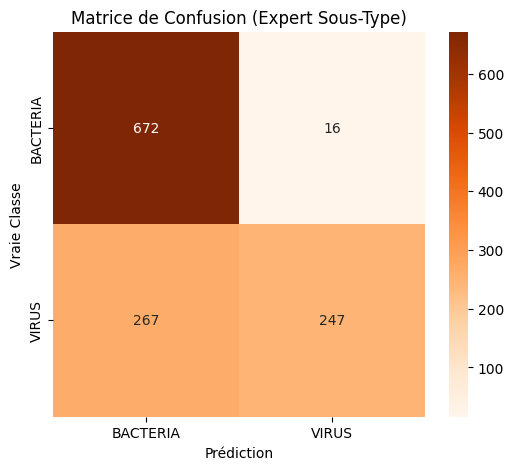

In [2]:
from src.data.data_loader_v3 import create_subtype_generators

print("⏳ Chargement des données de test (NORMAL ignoré)...")
_, test_subtype_gen, _ = create_subtype_generators("../data/raw/chest_Xray")

subtype_model = classifier.subtype_model

print("🔍 Prédiction sur le jeu de test (Bactérie vs Virus)...")
preds = subtype_model.predict(test_subtype_gen)
y_pred_sub = (preds > 0.5).astype(int).flatten()
y_true_sub = test_subtype_gen.classes

subtype_classes = ["BACTERIA", "VIRUS"]

print("\n📊 Rapport de Classification (Subtype) :")
print(classification_report(y_true_sub, y_pred_sub, target_names=subtype_classes))

cm_sub = confusion_matrix(y_true_sub, y_pred_sub)
plt.figure(figsize=(6,5))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Oranges', xticklabels=subtype_classes, yticklabels=subtype_classes)
plt.title('Matrice de Confusion (Expert Sous-Type)')
plt.ylabel('Vraie Classe')
plt.xlabel('Prédiction')
plt.show()